<a href="https://colab.research.google.com/github/elviraasch/Analisis-dan-Visualisasi-Data/blob/main/Analisis_dan_Visualisasi_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUGAS 1 - EDA**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
cancer_sur = pd.read_csv("haberman.csv")
cancer_sur.head()

,30,64,1,1.1
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [ ]:
cancer_sur = pd.read_csv("haberman.csv",
header=None, names=["Age","operation_year",
"axil_nodes_det","surv_status"])

In [ ]:
print(cancer_sur.describe())

              Age  operation_year  axil_nodes_det  surv_status
count  306.000000      306.000000      306.000000   306.000000
mean    52.457516       62.852941        4.026144     1.264706
std     10.803452        3.249405        7.189654     0.441899
min     30.000000       58.000000        0.000000     1.000000
25%     44.000000       60.000000        0.000000     1.000000
50%     52.000000       63.000000        1.000000     1.000000
75%     60.750000       65.750000        4.000000     2.000000
max     83.000000       69.000000       52.000000     2.000000


In [ ]:
cancer_sur.shape

(306, 4)

In [ ]:
cancer_sur["surv_status"].value_counts()

,count
surv_status,
1,225
2,81


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


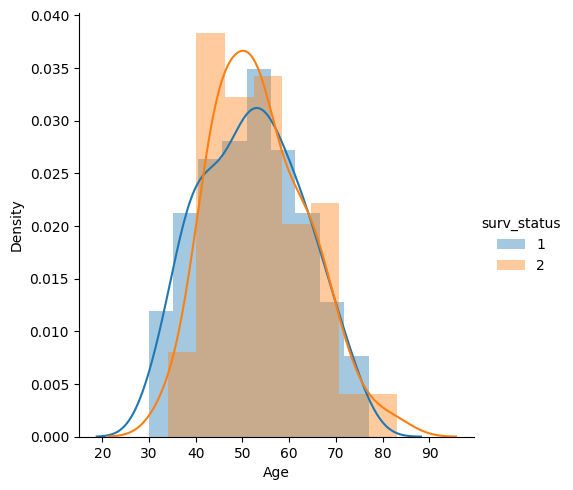

In [ ]:
sns.FacetGrid(cancer_sur,hue="surv_status",
height = 5).map(sns.distplot,
"Age").add_legend()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


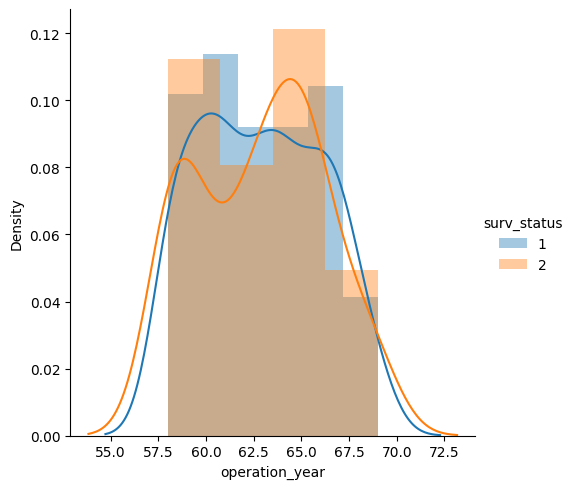

In [ ]:
sns.FacetGrid(cancer_sur,hue="surv_status",
height = 5).map(sns.distplot,
"operation_year").add_legend()

pdf= [0.05228758 0.08823529 0.1503268  0.17320261 0.17973856 0.13398693
 0.13398693 0.05882353 0.02287582 0.00653595]
bin_edges [30.  35.3 40.6 45.9 51.2 56.5 61.8 67.1 72.4 77.7 83. ]
cdf= [0.05228758 0.14052288 0.29084967 0.46405229 0.64379085 0.77777778
 0.91176471 0.97058824 0.99346405 1.        ]


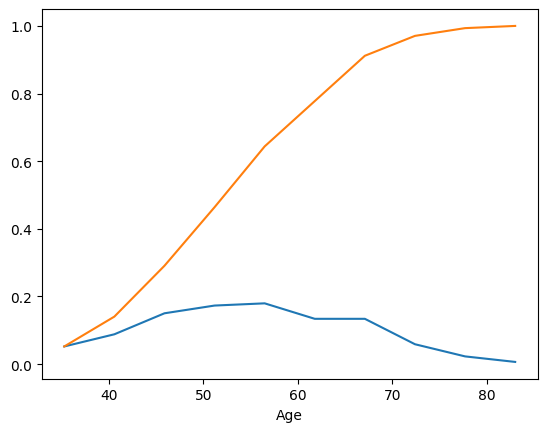

In [ ]:
counts, bin_edges = np.histogram(cancer_sur['Age'],
bins=10,density=True)
plt.xlabel('Age')
pdf = counts/(sum(counts))
print('pdf=', pdf);
print("bin_edges", bin_edges);
cdf = np.cumsum(pdf)
print("cdf=", cdf)
plt.plot(bin_edges[1:], pdf)
plt.plot(bin_edges[1:], cdf)

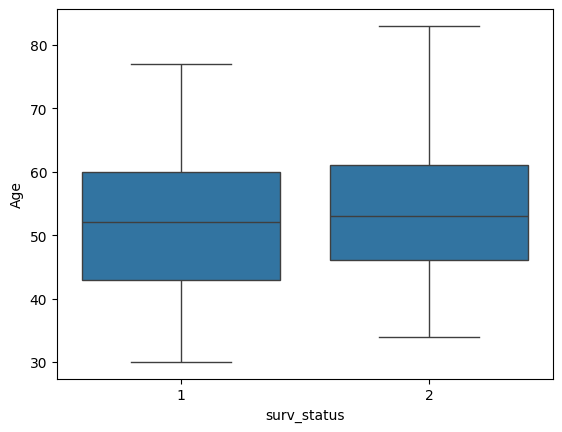

In [ ]:
sns.boxplot (x='surv_status', y ='Age', data= cancer_sur)
plt.show ()

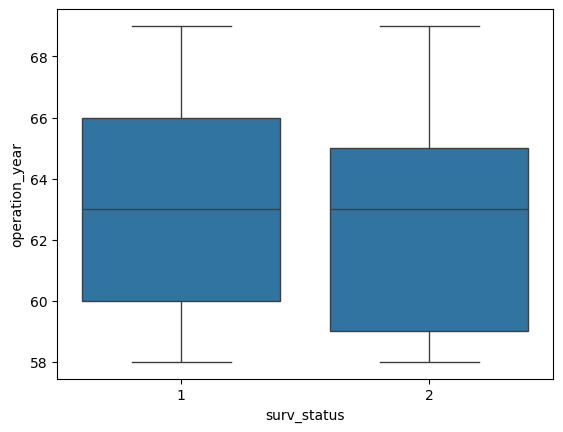

In [ ]:
sns.boxplot(x='surv_status', y ='operation_year', data= cancer_sur)
plt.show()

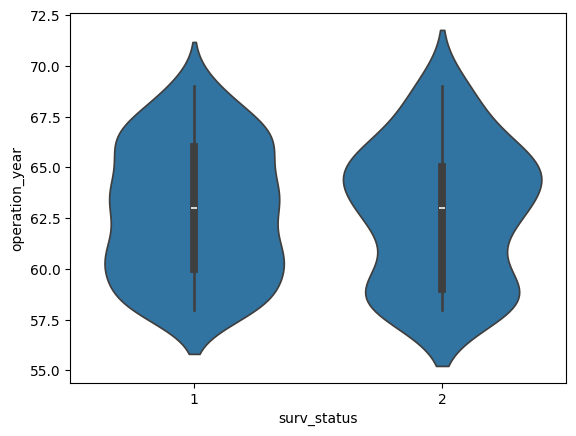

In [ ]:
sns.violinplot (x='surv_status', y ='operation_year', data = cancer_sur)
plt.show()

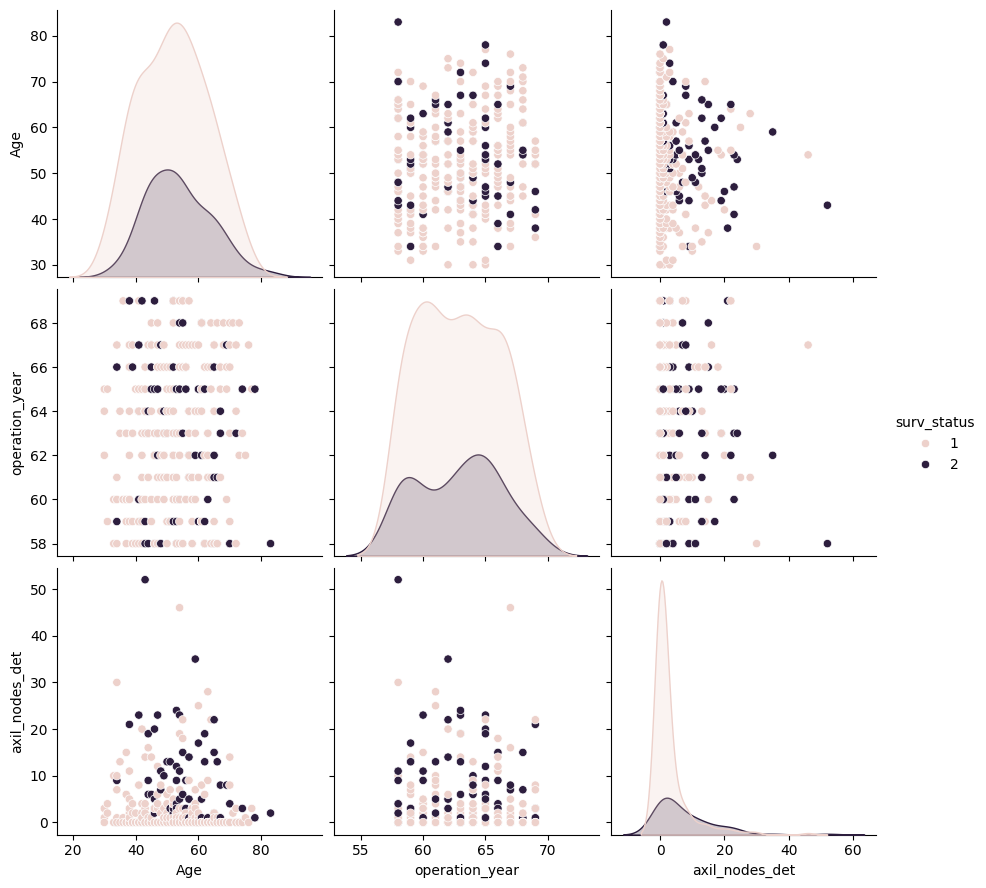

In [ ]:
sns.pairplot(cancer_sur,hue =
'surv_status', height= 3)
plt.show()

# **TUGAS 2 - POLICE**

In [ ]:
# Import the pandas library as pd
import pandas as pd

# Read 'police.csv' into a DataFrame named ri
ri = pd.read_csv('police.csv')

In [ ]:
combined = ri.stop_date.str.cat(ri.stop_time, sep=' ')

ri['stop_datetime'] = pd.to_datetime(combined)
ri['is_arrested'] = ri['is_arrested'].astype(bool)

ri.set_index('stop_datetime', inplace=True)

In [ ]:
# Calculate the overall arrest rate
print(ri.is_arrested.mean())

# Calculate the hourly arrest rate
print(ri.groupby(ri.index.hour).is_arrested.mean())

# Save the hourly arrest rate
hourly_arrest_rate = ri.groupby(ri.index.hour).is_arrested.mean()

0.09025408486936048
stop_datetime
0     0.121206
1     0.144250
2     0.144120
3     0.148370
4     0.179310
5     0.178899
6     0.043614
7     0.053497
8     0.073591
9     0.070199
10    0.069306
11    0.075217
12    0.087040
13    0.078964
14    0.080171
15    0.080526
16    0.089505
17    0.107914
18    0.089883
19    0.078508
20    0.091482
21    0.153265
22    0.110715
23    0.108225
Name: is_arrested, dtype: float64


Text(0.5, 1.0, 'Arrest Rate by Time of Day')

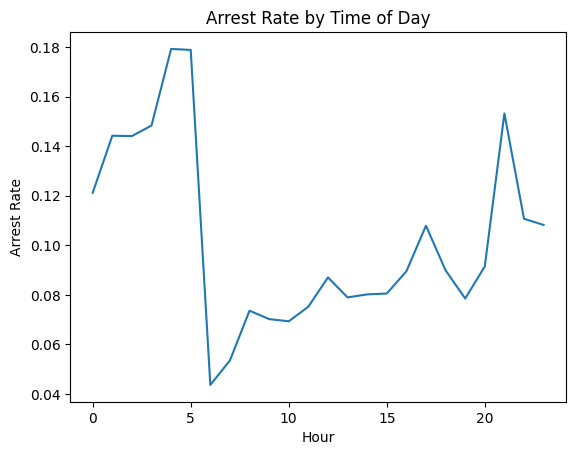

In [ ]:
import matplotlib.pyplot as plt

# Create a line plot of 'hourly_arrest_rate'
hourly_arrest_rate.plot()

# Add the xlabel, ylabel, and title
plt.xlabel('Hour')
plt.ylabel('Arrest Rate')
plt.title('Arrest Rate by Time of Day')

# Plotting drug-related stops

/tmp/ipykernel_1583/2249908190.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  print(ri.drugs_related_stop.resample('A').mean())
/tmp/ipykernel_1583/2249908190.py:5: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_drug_rate = ri.drugs_related_stop.resample('A').mean()


stop_datetime
2005-12-31    0.006390
2006-12-31    0.006913
2007-12-31    0.007520
2008-12-31    0.006998
2009-12-31    0.009079
2010-12-31    0.009407
2011-12-31    0.009035
2012-12-31    0.009388
2013-12-31    0.012283
2014-12-31    0.013280
2015-12-31    0.011787
Freq: YE-DEC, Name: drugs_related_stop, dtype: float64


<Axes: xlabel='stop_datetime'>

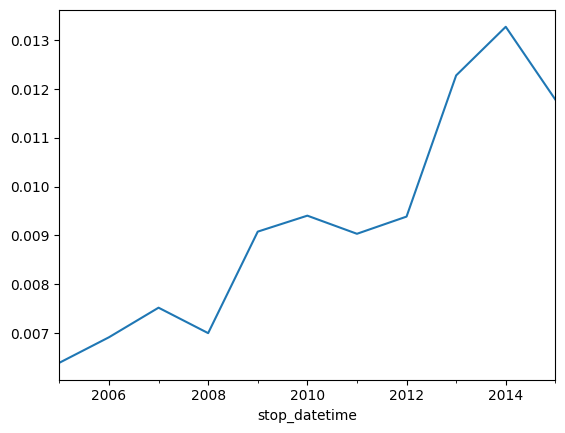

In [ ]:
# Calculate the annual rate of drug-related stops
print(ri.drugs_related_stop.resample('A').mean())

# Save the annual rate of drug-related stops
annual_drug_rate = ri.drugs_related_stop.resample('A').mean()

# Create a line plot of 'annual_drug_rate'
annual_drug_rate.plot()

/tmp/ipykernel_1583/2296526378.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_search_rate = ri.search_conducted.resample('A').mean()


array([<Axes: xlabel='stop_datetime'>, <Axes: xlabel='stop_datetime'>],
      dtype=object)

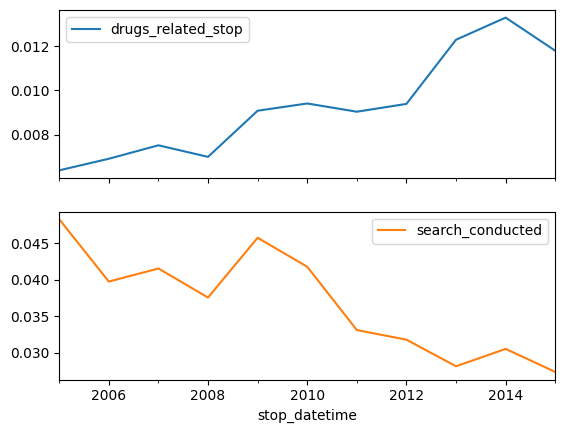

In [ ]:
# Calculate and save the annual search rate
annual_search_rate = ri.search_conducted.resample('A').mean()

# Concatenate 'annual_drug_rate' and 'annual_search_rate'
annual = pd.concat([annual_drug_rate, annual_search_rate], axis='columns')

# Create subplots from 'annual'
annual.plot(subplots=True)

In [ ]:
# Create a frequency table of districts and violations
print(pd.crosstab(ri.district, ri.violation))

# Save the frequency table as 'all_zones'
all_zones = pd.crosstab(ri.district, ri.violation)

# Select rows 'Zone K1' through 'Zone K3'
print(all_zones.loc['Zone K1':'Zone K3'])

# Save the smaller table as 'k_zones'
k_zones = all_zones.loc['Zone K1':'Zone K3']

violation  Equipment  Moving violation  Other  Registration/plates  Seat belt  \
district                                                                        
Zone K1          673              1254    290                  120          0   
Zone K2         2061              2962    942                  768        481   
Zone K3         2302              2898    706                  695        638   
Zone X1          296               671    143                   38         74   
Zone X3         2049              3086    769                  671        820   
Zone X4         3541              5353   1560                 1411        843   

violation  Speeding  
district             
Zone K1        5960  
Zone K2       10448  
Zone K3       12323  
Zone X1        1119  
Zone X3        8779  
Zone X4        9795  
violation  Equipment  Moving violation  Other  Registration/plates  Seat belt  \
district                                                                        
Zone K1      

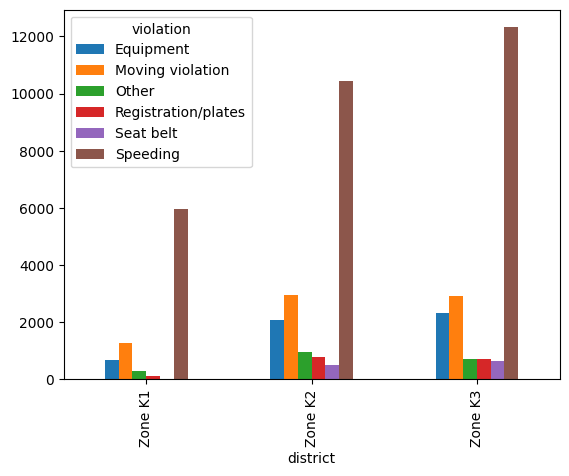

In [ ]:
import os
# Create a bar plot of 'k_zones'
k_zones.plot(kind='bar')
# Ensure the 'images' directory exists
os.makedirs('images', exist_ok=True)
plt.savefig('images/k-zones-plot.png')

<Axes: xlabel='district'>

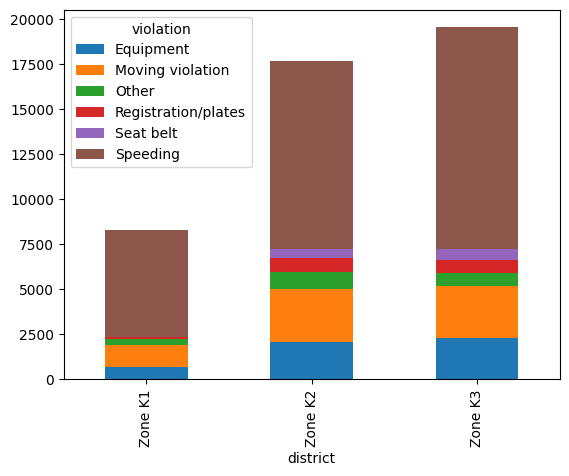

In [ ]:
# Create a stacked bar plot of 'k_zones'
k_zones.plot(kind='bar', stacked=True)

In [ ]:
# Print the unique values in 'stop_duration'
print(ri.stop_duration.unique())

# Create a dictionary that maps strings to integers
mapping = {'0-15 Min': 8, '16-30 Min': 23, '30+ Min': 45}

# Convert the 'stop_duration' strings to intergers using the 'mapping'
ri['stop_minutes'] = ri.stop_duration.map(mapping)

# Print the unique values in 'stop_minutes'
print(ri.stop_minutes.unique())

['0-15 Min' '16-30 Min' nan '30+ Min']
[ 8. 23. nan 45.]


violation_raw
APB                                 17.967033
Call for Service                    22.140805
Equipment/Inspection Violation      11.445340
Motorist Assist/Courtesy            17.741463
Other Traffic Violation             13.844490
Registration Violation              13.736970
Seatbelt Violation                   9.662815
Special Detail/Directed Patrol      15.123632
Speeding                            10.581509
Suspicious Person                   14.910714
Violation of City/Town Ordinance    13.254144
Warrant                             24.055556
Name: stop_minutes, dtype: float64


<Axes: ylabel='violation_raw'>

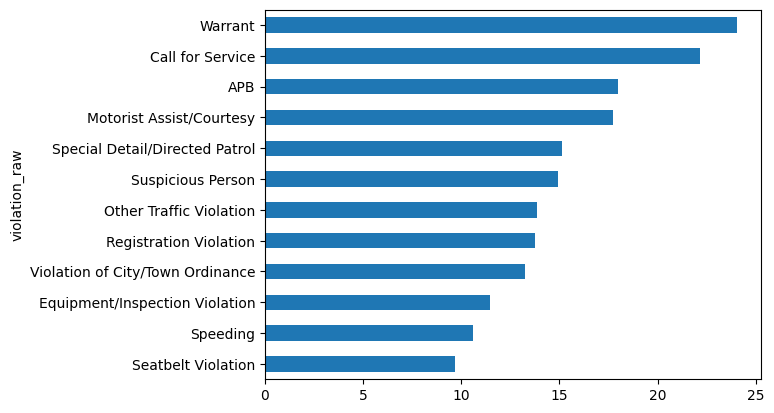

In [ ]:
# Calculate the mean 'stop_minutes' for each value in 'violation_raw'
print(ri.groupby('violation_raw').stop_minutes.mean())

# Save the resulting Series as 'stop_length'
stop_length = ri.groupby('violation_raw').stop_minutes.mean()

# Sort 'stop_length' by its values and create a horizontal bar plot
stop_length.sort_values().plot(kind='barh')